# 03 — D3 `clustering_gmm`: GMM estático (baseline NO temporal)

**Familia CLUSTERING.** Un *Gaussian Mixture Model* (GMM) modela los datos como una mezcla de varias gaussianas: cada día se asigna al componente —el régimen— bajo el que resulta más probable. Aquí lo ajustamos con `covariance_type='full'` (cada régimen tiene su matriz de covarianza completa) sobre las **15 features causales** del EDA, lo que le permite separar regímenes que difieren no solo en volatilidad sino en la **estructura de correlación entre activos** —por ejemplo el cambio de signo de la correlación renta variable/bonos (Gulko 2002)—, algo que un *k-means* euclídeo o un GMM diagonal no captarían.

**Qué lo hace un baseline, y de qué.** El GMM no tiene cadena de Markov ni término de persistencia: clasifica cada día de forma INDEPENDIENTE, sin memoria del estado de ayer. Es deliberadamente el detector contra el que D4 (un HMM con las mismas features) medirá **cuánto aporta la dinámica temporal**: la diferencia de persistencia entre ambos aísla el efecto de añadir una matriz de transición.

**Hipótesis (CHECKPOINT 2):** *captará regímenes con estructura de correlación distinta (gracias a la covarianza full); fallará por flickering severo —parpadeo de las etiquetas de un día para otro, al no haber persistencia—; y no es causal de forma nativa* (la causalidad se la impone el `walk_forward`, no el modelo).

**Política de ventana y su límite.** Las 15 features arrancan en **2007-07**, así que el primer train (expanding, 8 años) consume 2007–2015. Por construcción **2008 (GFC) y 2011 (deuda europea) NO son OOS-evaluables** —caen dentro del primer train— y su cobertura saldrá `NaN`. No es un fallo del detector: es la consecuencia honesta de no penalizar lo que el modelo no pudo ver fuera de muestra.

Detalle en `docs/memory/detectors/03_clustering_gmm.md`.

## Índice navegable

**Bloque A — selección, sanidad y evaluación causal**
1. [Selección de *k* por BIC (in-sample, guía)](#s1)
2. [Sanidad económica: orden canónico y retorno por estado](#s2)
3. [Walk-forward CAUSAL + evaluación estandarizada](#s3)
4. [Tabla de métricas (esquema común) y volcado a `results/`](#s4)

**Bloque B — el mecanismo del GMM, por fin visible (ampliación de esta revisión)**
5. [Espacio de 15 features (PCA 2D) por componente GMM](#s5) — *figura nueva* `d03_feature_scatter.png`
6. [Estructura de covarianza por componente (full Σ)](#s6) — *figura nueva* `d03_cov_by_component.png`
7. [Paisaje BIC vs *k* y confianza de las asignaciones](#s7) — *figura nueva* `d03_bic_curve.png`

**Bloque C — flickering, recorrido y veredicto**
8. [Flickering: `switching_rate` e histograma de duraciones](#s8) — `d03_gmm_flickering.png`
9. [S&P 500 coloreado por régimen (OOS)](#s9) — `d03_gmm_sp500_regimes.png`
10. [Timeline de estado y P(crisis) OOS](#s10) — `d03_gmm_timeline.png`
11. [Verificación contra crisis y trampas](#s11)
12. [Conclusión — veredicto "mejor-para-qué"](#s12)

> **Mapa de lectura.** El **Bloque A** fija *k* por BIC, canonicaliza los estados (0 = calma … n−1 = crisis) y los evalúa de forma CAUSAL walk-forward. El **Bloque B** —la ampliación de esta revisión— abre la caja negra y hace *visible el mecanismo* del GMM: cómo separa los tres regímenes en el espacio de features y cómo difiere la matriz de covarianza **full** de cada gaussiana (el cambio de estructura de correlación renta variable/bonos de Gulko 2002). El **Bloque C** documenta el *flickering* —el talón de Aquiles que motiva los detectores temporales (D4)— y cierra con el veredicto "mejor-para-qué".

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

from src import evaluation as ev
from src import viz
viz.use_house_style()  # rcParams homogeneos (estilo de casa, paleta consistente)
from detectors.clustering_gmm import ClusteringGMM

X = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
# market_returns = retorno log S&P 500 reindexado a las features.
market_returns = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)
spx = raw['SP500'].reindex(X.index)
print('Features:', X.shape, '| ventana', X.index.min().date(), '->', X.index.max().date())
X.columns.tolist()

Features: (4665, 15) | ventana 2007-07-06 -> 2026-06-12


['SP500_ret_z',
 'SP500_vol_z',
 'VIX_level_z',
 'VIX_change_z',
 'MOVE_level_z',
 'TLT_ret_z',
 'IEF_ret_z',
 'HYG_ret_z',
 'credit_spread_z',
 'yield_slope_z',
 'DXY_change_z',
 'GOLD_ret_z',
 'corr_spx_bond',
 'SP500_drawdown',
 'SP500_momentum']

<a id="s1"></a>
## 1. Selección del número de estados por BIC (in-sample, solo como guía)

¿Cuántos regímenes *k*? El GMM expone una log-verosimilitud, así que usamos el **BIC** (*Bayesian Information Criterion*: premia el ajuste pero penaliza el número de parámetros; menor es mejor) para comparar k=2 frente a k=3 sobre todo el panel.

**Honestidad metodológica:** este BIC es *in-sample* —se calcula viendo toda la muestra, con look-ahead— y sirve solo de **guía** para fijar *k*; la evaluación que de verdad cuenta es la walk-forward causal de la §3. Lo declaramos explícitamente porque elegir *k* mirando el futuro es una fuga sutil que no debe confundirse con el rendimiento out-of-sample.

In [2]:
rows = []
for k in (2, 3):
    d = ClusteringGMM(n_states=k).fit(X)
    rows.append({'k': k, 'log_likelihood': d.score(X), 'n_params': d.n_parameters(),
                 'AIC': d.aic(X), 'BIC': d.bic(X)})
bic_tbl = pd.DataFrame(rows).set_index('k')
K_BIC = int(bic_tbl['BIC'].idxmin())
print('k elegido por BIC:', K_BIC)
bic_tbl.round(1)

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


k elegido por BIC: 3


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


,log_likelihood,n_params,AIC,BIC
k,,,,
2,-34343.0,271,69227.9,70975.3
3,-29789.0,407,60392.0,63016.2


<a id="s2"></a>
## 2. Sanidad económica: orden canónico y retorno medio por estado

Antes de evaluar, comprobamos que las etiquetas significan lo que decimos que significan. Tras `fit`, `label_states_economically` reordena los componentes al **orden canónico** (0 = calma … n−1 = crisis) usando el retorno del S&P 500. Verificamos dos cosas: (i) que el retorno medio del índice **decrece** del estado de calma al de crisis —es decir, el estado etiquetado "crisis" es realmente el de peor retorno y mayor volatilidad—, y (ii) que `predict_proba` queda en ese orden, de modo que su **última columna es P(crisis)**. Sin esta sanidad, una métrica de cobertura podría estar leyendo el régimen invertido y dar números engañosos.

In [3]:
det_full = ClusteringGMM(n_states=K_BIC).fit(X)
states_is = pd.Series(det_full.predict(X), index=X.index)
proba_is = det_full.predict_proba(X)
ret_by_state = {int(s): float(market_returns[states_is == s].mean()) for s in np.unique(states_is)}
vol_by_state = {int(s): float(market_returns[states_is == s].std()) for s in np.unique(states_is)}
print('crisis_state (canónico):', det_full.crisis_state)
print('predict_proba filas suman 1:', np.allclose(proba_is.sum(axis=1), 1.0))
pd.DataFrame({'mean_ret': ret_by_state, 'std_ret': vol_by_state,
              'n_dias': states_is.value_counts().sort_index()}).round(5)

crisis_state (canónico): 2
predict_proba filas suman 1: True


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


,mean_ret,std_ret,n_dias
0,0.00102,0.00696,2127
1,0.00047,0.00897,1687
2,-0.00190,0.02397,851


<a id="s3"></a>
## 3. Walk-forward CAUSAL + evaluación estandarizada

Aquí está el corazón causal del banco de pruebas. `ev.walk_forward` re-ajusta el GMM en ventana **expanding** (train inicial de 8 años, re-fit cada 21 días) y, en cada paso, clasifica el bloque siguiente usando SOLO el pasado: ningún día se etiqueta con información posterior a esa fecha. Cada fold canonicaliza sus propios estados, lo que resuelve el alineado de etiquetas entre folds —el componente "crisis" que ve un fold y el que ve otro reciben la misma etiqueta económica—. Evaluamos k=2 y k=3 bajo idéntico protocolo; el detector principal que se vuelca a `results/` es el *k* elegido por BIC.

In [4]:
def run(k):
    panel = ev.walk_forward(lambda: ClusteringGMM(n_states=k), X,
                            train_size=252*8, step=21, expanding=True)
    det = ClusteringGMM(n_states=k).fit(X)
    res = ev.evaluate(det, panel, market_returns=market_returns, X_full=X)
    return panel, det, res

panel2, det2, res2 = run(2)
panel3, det3, res3 = run(3)
panels = {2: panel2, 3: panel3}
results = {2: res2, 3: res3}
panel = panels[K_BIC]; det = {2: det2, 3: det3}[K_BIC]; res = results[K_BIC]
print('Detector principal:', det.name)
print('Ventana OOS:', res.extra['ventana_eval'])

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


...

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


Detector principal: clustering_gmm_k3
Ventana OOS: 2015-09-15→2026-06-12 (n=2649)


<a id="s4"></a>
## 4. Tabla de métricas (esquema común) y volcado a `results/`

`ev.results_table` produce la fila estandarizada —las mismas columnas para los 12 detectores del banco—, que es lo que hace a D3 comparable con el resto bajo el marco único. Guardamos el detector principal (el *k* elegido por BIC) en `results/metrics_03_clustering_gmm.csv`.

In [5]:
tbl = ev.results_table([results[2], results[3]])
cols = ['detector','n_states','ventana_eval','switching_rate','mean_regime_duration',
        'label_stability','false_alarm_rate','bic',
        'cov_COVID_2020','cov_Inflation_2022','cov_GFC_2008','cov_EuroDebt_2011',
        'fa_TaperTantrum_2013','fa_Selloff_Q4_2018']
display(tbl[cols].round(3).T)
out_csv = RESULTS / 'metrics_03_clustering_gmm.csv'
ev.results_table([res]).to_csv(out_csv, index=False)
print('Guardado:', out_csv, '| filas:', len(ev.results_table([res])))

,0,1
detector,clustering_gmm_k2,clustering_gmm_k3
n_states,2,3
ventana_eval,2015-09-15→2026-06-12 (n=2649),2015-09-15→2026-06-12 (n=2649)
switching_rate,0.112,0.126
mean_regime_duration,8.889,7.907
label_stability,0.989,0.976
false_alarm_rate,0.753,0.494
bic,70975.283,63016.246
cov_COVID_2020,0.96,0.96
cov_Inflation_2022,0.851,0.865


Guardado: C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\results\metrics_03_clustering_gmm.csv | filas: 1


<a id="s5"></a>
## 5. Espacio de 15 features (PCA 2D) coloreado por componente GMM

Hasta aquí el GMM ha sido una caja negra que reparte etiquetas. Esta sección la abre. Un GMM **es**, literalmente, una partición del espacio de features en regiones gobernadas por gaussianas; su visualización natural es por tanto el *scatter* de ese espacio coloreado por el componente asignado. Como trabajamos con **15 features causales**, proyectamos a 2D con PCA (estandarizando antes, sin look-ahead operativo: es un retrato in-sample, igual que el BIC de la §1) y pintamos cada día con el color de su régimen canónico (azul calma → ámbar intermedio → rojo crisis).

Qué leer aquí: que los tres componentes ocupen regiones **distinguibles** —si se solaparan por completo, el GMM no estaría separando nada—, con la **crisis empujada hacia la cola** del espacio (alta volatilidad / co-movimiento atípico) y el régimen intermedio actuando de puente. El solape residual en la frontera entre nubes es, anticipándolo, el caldo de cultivo del *flickering* de la §8: días ambiguos cuyo posterior se reparte entre componentes y que, sin memoria temporal, saltan de etiqueta de una jornada a la siguiente.

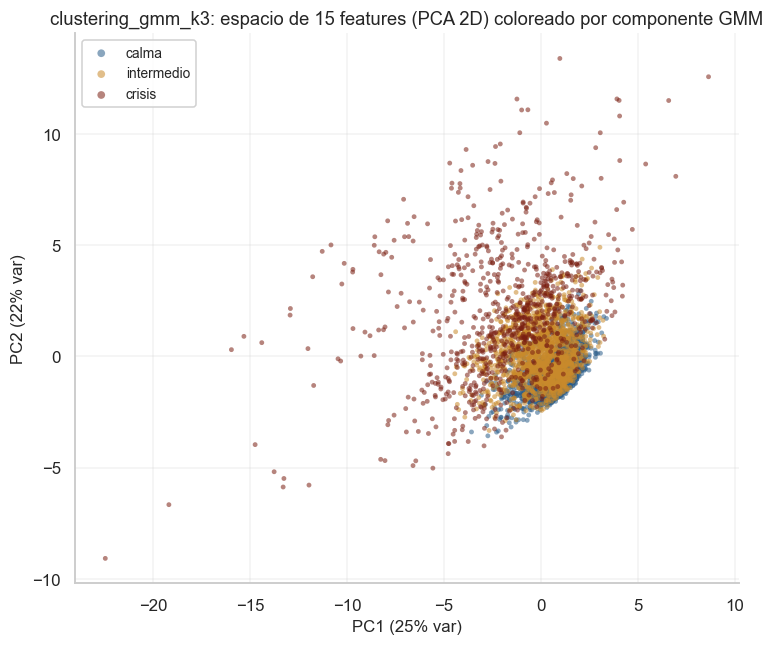

Tamano de cada componente (in-sample):
  estado 0 (calma): 2127 dias (45.6%)
  estado 1 (intermedio): 1687 dias (36.2%)
  estado 2 (crisis): 851 dias (18.2%)


In [6]:
REG_LABELS = ({0: 'calma', 1: 'intermedio', 2: 'crisis'} if det.n_states == 3
              else {0: 'calma', det.n_states - 1: 'crisis'})
ax = viz.plot_feature_space_scatter(
    X, states_is, use_pca=True, crisis_state=det.crisis_state, labels=REG_LABELS,
    title=f'{det.name}: espacio de 15 features (PCA 2D) coloreado por componente GMM')
ax.figure.savefig(RESULTS / 'd03_feature_scatter.png', dpi=110, bbox_inches='tight')
plt.show()
print('Tamano de cada componente (in-sample):')
for s, n in states_is.value_counts().sort_index().items():
    print(f'  estado {int(s)} ({REG_LABELS.get(int(s), s)}): {n} dias ({100*n/len(states_is):.1f}%)')

<a id="s6"></a>
## 6. Estructura de covarianza por componente (el mecanismo de la covarianza *full*)

Aquí se ve *por qué* elegimos `covariance_type='full'`. Cada gaussiana del GMM tiene su propia matriz de covarianza Σ_k; con covarianza full, esa Σ_k puede capturar no solo **escalas de volatilidad** distintas sino **estructuras de correlación** distintas entre las 15 features. Pintamos, para cada componente, la matriz de correlación empírica de las features de los días asignados a ese régimen.

La lectura clave —el cambio de régimen de la correlación renta variable/bonos (Gulko 2002)— aparece como un **reordenamiento del patrón de correlaciones** entre calma y crisis: un *k-means* euclídeo o un GMM diagonal, ciegos a la covarianza cruzada, no podrían separar regímenes que difieren *solo* en esa estructura. La **distancia de Frobenius** entre las matrices por componente cuantifica cuánto difieren: si fuera ~0, la covarianza full no aportaría nada sobre una diagonal.

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\viz.py:650: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


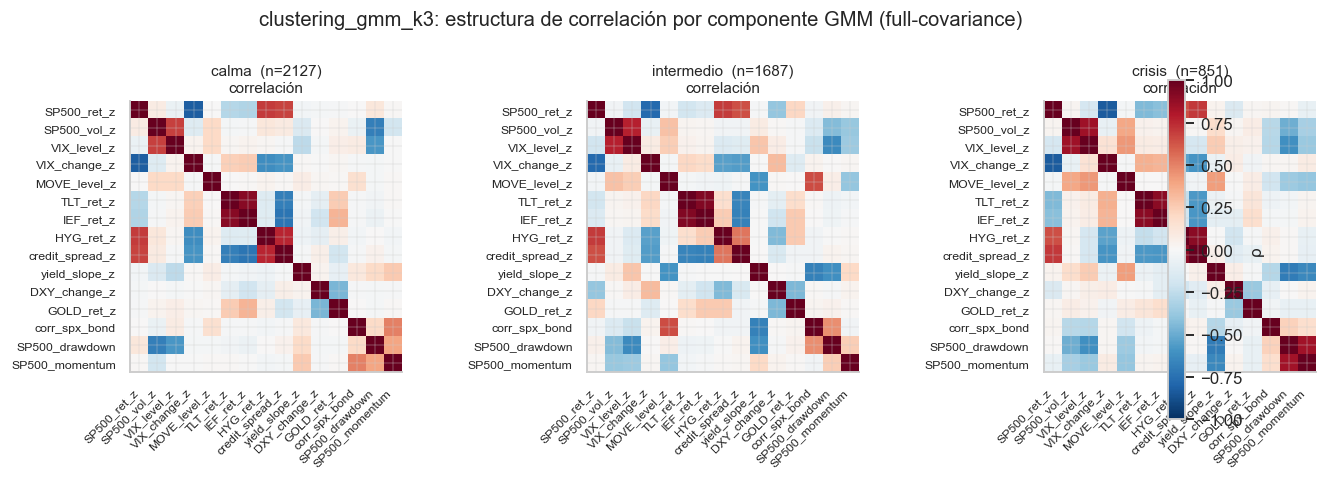

Distancia de Frobenius entre estructuras de correlacion por componente:
  ||corr(estado 0) - corr(estado 1)||_F = 2.91
  ||corr(estado 0) - corr(estado 2)||_F = 2.81
  ||corr(estado 1) - corr(estado 2)||_F = 3.02

Feature de correlacion detectada: 'corr_spx_bond' -- media por regimen:
  estado 0 (calma): -0.297
  estado 1 (intermedio): -0.229
  estado 2 (crisis): -0.385
-> Sigma_k difiere por componente: ese es el aporte de covariance_type full (Gulko 2002).


In [7]:
import itertools
fig = viz.plot_regime_correlation_heatmaps(
    X, states_is, labels=REG_LABELS, precision=False,
    title=f'{det.name}: estructura de correlación por componente GMM (full-covariance)')
fig.savefig(RESULTS / 'd03_cov_by_component.png', dpi=110, bbox_inches='tight')
plt.show()

def _regcorr(s):
    sub = X.values[states_is.values == s]
    return np.corrcoef(sub, rowvar=False)
mats = {int(s): _regcorr(s) for s in np.unique(states_is)}
fro = lambda A, B: float(np.linalg.norm(A - B))
print('Distancia de Frobenius entre estructuras de correlacion por componente:')
for a, b in itertools.combinations(sorted(mats), 2):
    print(f'  ||corr(estado {a}) - corr(estado {b})||_F = {fro(mats[a], mats[b]):.2f}')
corrcol = next((c for c in X.columns if 'corr' in c.lower()), None)
if corrcol is not None:
    print(f'\nFeature de correlacion detectada: {corrcol!r} -- media por regimen:')
    for s in sorted(int(u) for u in np.unique(states_is)):
        print(f'  estado {s} ({REG_LABELS.get(s, s)}): {X[corrcol][states_is.values == s].mean():+.3f}')
print('-> Sigma_k difiere por componente: ese es el aporte de covariance_type full (Gulko 2002).')

<a id="s7"></a>
## 7. Paisaje BIC vs *k* y confianza de las asignaciones

La §1 decidió *k* comparando los dos candidatos operativos (k=2 vs k=3) que después se evalúan OOS. Aquí ampliamos la mirada con dos diagnósticos complementarios.

- **(Izquierda) Paisaje BIC/AIC para k=2…6.** El BIC suele seguir bajando al añadir componentes, pero la **mejora marginal se aplana** y los componentes extra dejan de tener lectura económica; por eso fijamos la taxonomía en **tres regímenes interpretables** (calma / intermedio / crisis), coherente con la práctica habitual y con D4. La línea vertical marca el *k* elegido por BIC entre los candidatos. Recordatorio de honestidad: este BIC es *in-sample* (§1) y solo es una **guía**; la evaluación que cuenta es la causal de la §3.
- **(Derecha) Distribución de la máxima responsabilidad** P(estado | x) por régimen: cuán confiada es cada asignación. Responsabilidades cercanas a 1 son días inequívocos; las colas bajas son **días-frontera** donde el posterior se reparte entre componentes —precisamente los que, sin persistencia temporal, alimentan el *flickering* de la §8—.

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k4: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k5: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k6: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


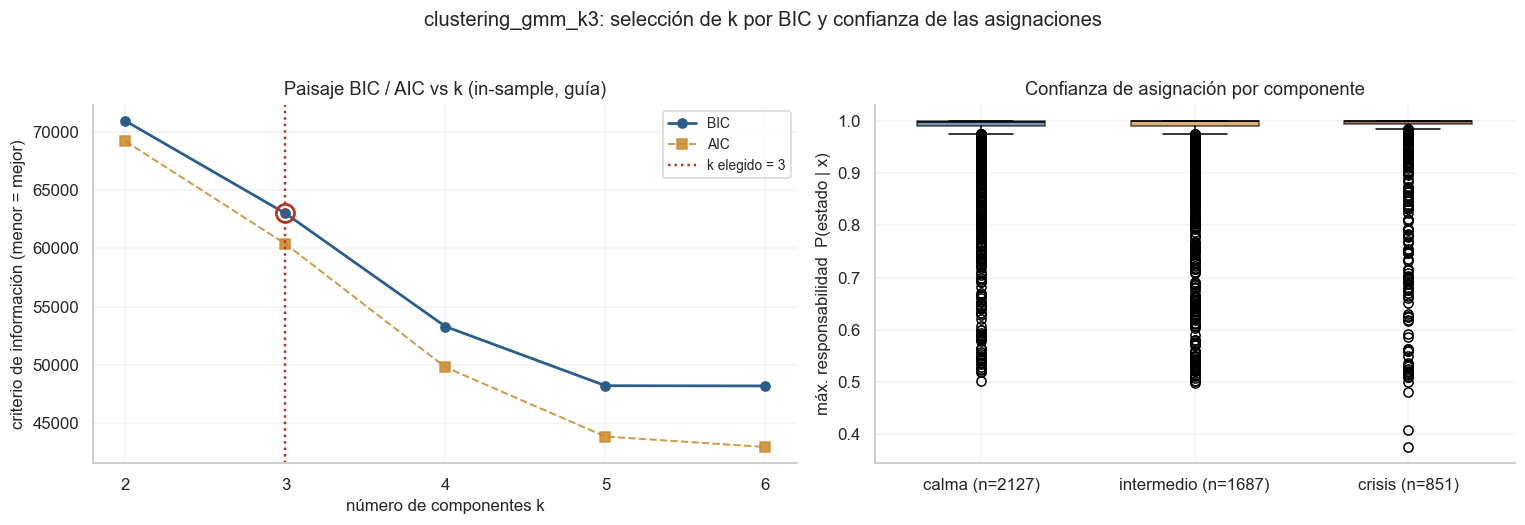

BIC/AIC por k (in-sample, guia):
       BIC      AIC
k                  
2  70975.0  69228.0
3  63016.0  60392.0
4  53281.0  49780.0
5  48190.0  43812.0
6  48169.0  42914.0

Confianza media de asignacion: 0.97 | % dias con responsabilidad < 0.6 (frontera): 2.0%


In [8]:
ks = list(range(2, 7))
scan = []
for k in ks:
    dk = ClusteringGMM(n_states=k).fit(X)
    scan.append({'k': k, 'BIC': dk.bic(X), 'AIC': dk.aic(X)})
scan = pd.DataFrame(scan).set_index('k')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={'width_ratios': [1.1, 1]})
axL.plot(scan.index, scan['BIC'], 'o-', color=viz.C_LONG, lw=1.8, label='BIC')
axL.plot(scan.index, scan['AIC'], 's--', color=viz.C_SHORT, lw=1.3, alpha=0.85, label='AIC')
axL.axvline(K_BIC, color=viz.C_CRISIS, ls=':', lw=1.6, label=f'k elegido = {K_BIC}')
axL.scatter([K_BIC], [scan.loc[K_BIC, 'BIC']], s=140, facecolors='none',
            edgecolors=viz.C_CRISIS, linewidths=1.8, zorder=5)
axL.set_xticks(ks); axL.set_xlabel('número de componentes k')
axL.set_ylabel('criterio de información (menor = mejor)')
axL.set_title('Paisaje BIC / AIC vs k (in-sample, guía)')
axL.legend(fontsize=9)
conf = pd.Series(proba_is.max(axis=1), index=X.index)
viz.plot_distribution_by_regime(
    conf, states_is, kind='box', labels=REG_LABELS, ax=axR,
    xlabel='máx. responsabilidad  P(estado | x)',
    title='Confianza de asignación por componente')
fig.suptitle(f'{det.name}: selección de k por BIC y confianza de las asignaciones', y=1.03)
fig.tight_layout(); fig.savefig(RESULTS / 'd03_bic_curve.png', dpi=110, bbox_inches='tight')
plt.show()
print('BIC/AIC por k (in-sample, guia):'); print(scan.round(0))
print(f'\nConfianza media de asignacion: {conf.mean():.2f} | '
      f'% dias con responsabilidad < 0.6 (frontera): {100*(conf < 0.6).mean():.1f}%')

<a id="s8"></a>
## 8. Flickering: `switching_rate` e histograma de duraciones de régimen

Aquí se ve el **talón de Aquiles** anunciado en la hipótesis. *Flickering* es el parpadeo de las etiquetas: como el GMM clasifica cada día sin memoria (no hay matriz de transición que premie permanecer en el mismo régimen), las rachas se fragmentan en episodios irrealmente cortos. Lo cuantificamos con dos lecturas: el `switching_rate` (fracción de días en que el estado cambia respecto al anterior) y la distribución de duraciones de cada racha. Este número es justo el que D4, al añadir persistencia markoviana, deberá **reducir**: aquí se fija la línea base del problema que motiva los detectores temporales.

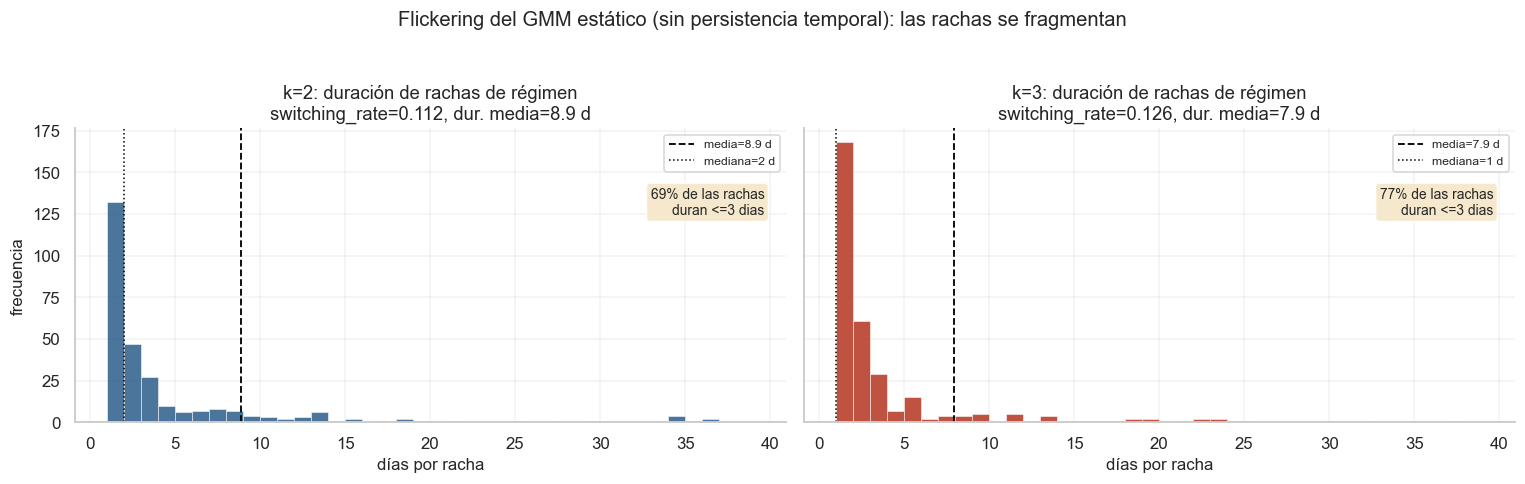

% rachas <=3 dias (k=3): 77.0%


In [9]:
def run_lengths(states):
    v = np.asarray(states); idx = np.where(np.diff(v) != 0)[0]
    bounds = np.concatenate(([-1], idx, [len(v)-1]))
    return np.diff(bounds)

rl2 = run_lengths(panel2['state'].values)
rl3 = run_lengths(panel3['state'].values)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for a, rl, r, k, col in zip(ax, (rl2, rl3), (res2, res3), (2, 3), (viz.C_LONG, viz.C_CRISIS)):
    a.hist(rl, bins=range(1, 40), color=col, alpha=0.85, edgecolor='white', linewidth=0.4)
    a.axvline(rl.mean(), color='black', ls='--', lw=1.2, label=f'media={rl.mean():.1f} d')
    a.axvline(np.median(rl), color='black', ls=':', lw=1.0, label=f'mediana={np.median(rl):.0f} d')
    pct = 100 * (rl <= 3).mean()
    a.text(0.97, 0.80, f'{pct:.0f}% de las rachas\nduran <=3 dias',
           transform=a.transAxes, ha='right', va='top', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='#f6e6c8', alpha=0.9))
    a.set_title(f'k={k}: duración de rachas de régimen\n'
                f'switching_rate={r.switching_rate:.3f}, dur. media={r.mean_regime_duration:.1f} d')
    a.set_xlabel('días por racha'); a.legend(fontsize=8)
ax[0].set_ylabel('frecuencia')
fig.suptitle('Flickering del GMM estático (sin persistencia temporal): las rachas se fragmentan', y=1.04)
fig.tight_layout(); fig.savefig(RESULTS / 'd03_gmm_flickering.png', dpi=110, bbox_inches='tight')
plt.show()
print('%% rachas <=3 dias (k=%d): %.1f%%' % (K_BIC, 100*(run_lengths(panel['state'].values) <= 3).mean()))

<a id="s9"></a>
## 9. S&P 500 coloreado por régimen (OOS) con ventanas de crisis

Lectura visual del flickering. El sombreado de fondo es el estado canónico OOS asignado cada día (verde = calma → rojo = crisis); las franjas verticales marcan las ventanas de crisis conocidas (rojo) y las trampas / falsos positivos (naranja). El síntoma a buscar: el fondo cambia de color constantemente en lugar de mantener bloques limpios por régimen —exactamente el comportamiento que un detector con persistencia debería evitar—.

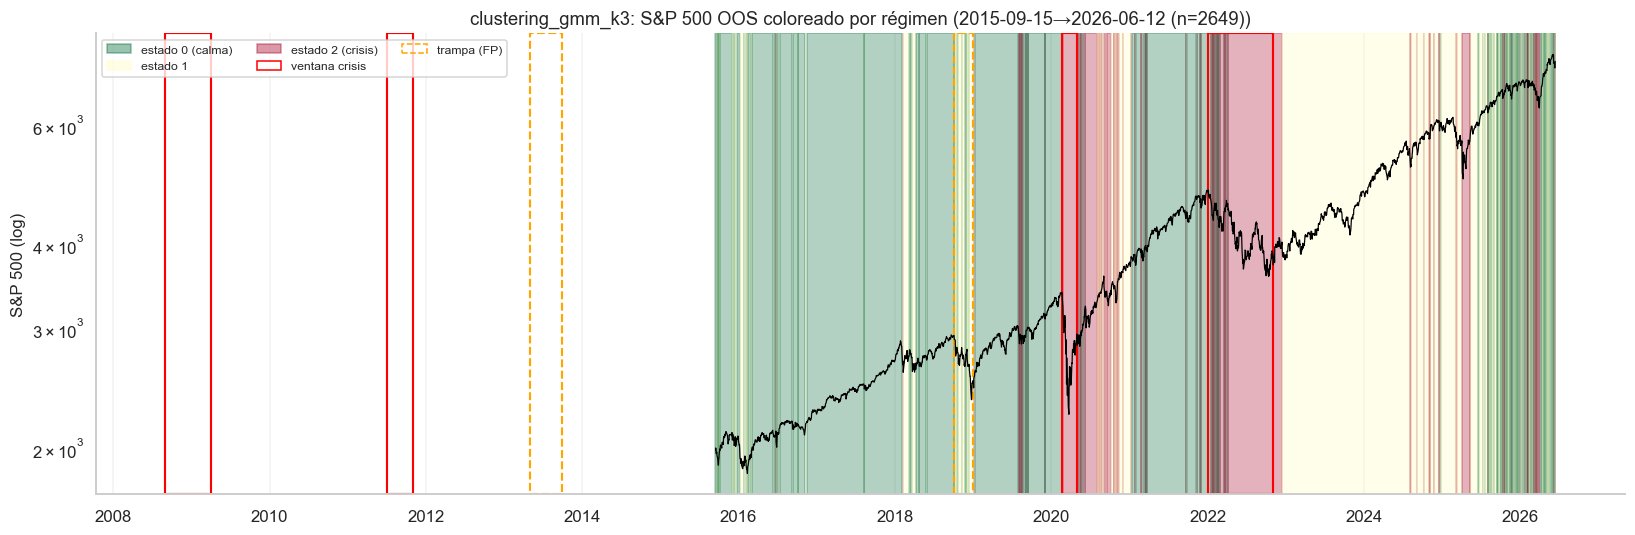

In [10]:
from matplotlib.colors import to_rgba
st = panel['state']
px = spx.reindex(st.index)
k = det.n_states
cmap = plt.cm.RdYlGn_r
state_colors = {s: cmap(s / max(1, k - 1)) for s in range(k)}
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(px.index, px.values, color='black', lw=0.8, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
# sombreado por estado (tramos contiguos)
vals = st.values; idx = st.index
changes = np.where(np.diff(vals) != 0)[0]
starts = np.concatenate(([0], changes + 1)); ends = np.concatenate((changes, [len(vals)-1]))
for s0, e0 in zip(starts, ends):
    ax.axvspan(idx[s0], idx[e0], color=to_rgba(state_colors[vals[s0]], 0.30), zorder=1)
for name, (a, b) in ev.CRISIS_WINDOWS.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), facecolor='none', edgecolor='red', lw=1.4, zorder=2)
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), facecolor='none', edgecolor='orange', lw=1.4, ls='--', zorder=2)
legend = [Patch(color=state_colors[s], alpha=0.4, label=f'estado {s}' + (' (crisis)' if s==k-1 else (' (calma)' if s==0 else ''))) for s in range(k)]
legend += [Patch(facecolor='none', edgecolor='red', label='ventana crisis'),
           Patch(facecolor='none', edgecolor='orange', ls='--', label='trampa (FP)')]
ax.legend(handles=legend, ncol=3, fontsize=8, loc='upper left')
ax.set_title(f'{det.name}: S&P 500 OOS coloreado por régimen (' + res.extra['ventana_eval'] + ')')
fig.tight_layout(); fig.savefig(RESULTS / 'd03_gmm_sp500_regimes.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="s10"></a>
## 10. Timeline de estado y probabilidad de crisis OOS

Dos vistas complementarias del mismo recorrido OOS. Arriba, el estado canónico día a día (función escalón). Abajo, la **probabilidad continua de crisis** `predict_proba[:, crisis_state]`, que matiza la decisión dura: deja ver con cuánta confianza el GMM marca cada día y dónde duda. Las ventanas de crisis (rojo) y de trampa (naranja) sirven de referencia visual.

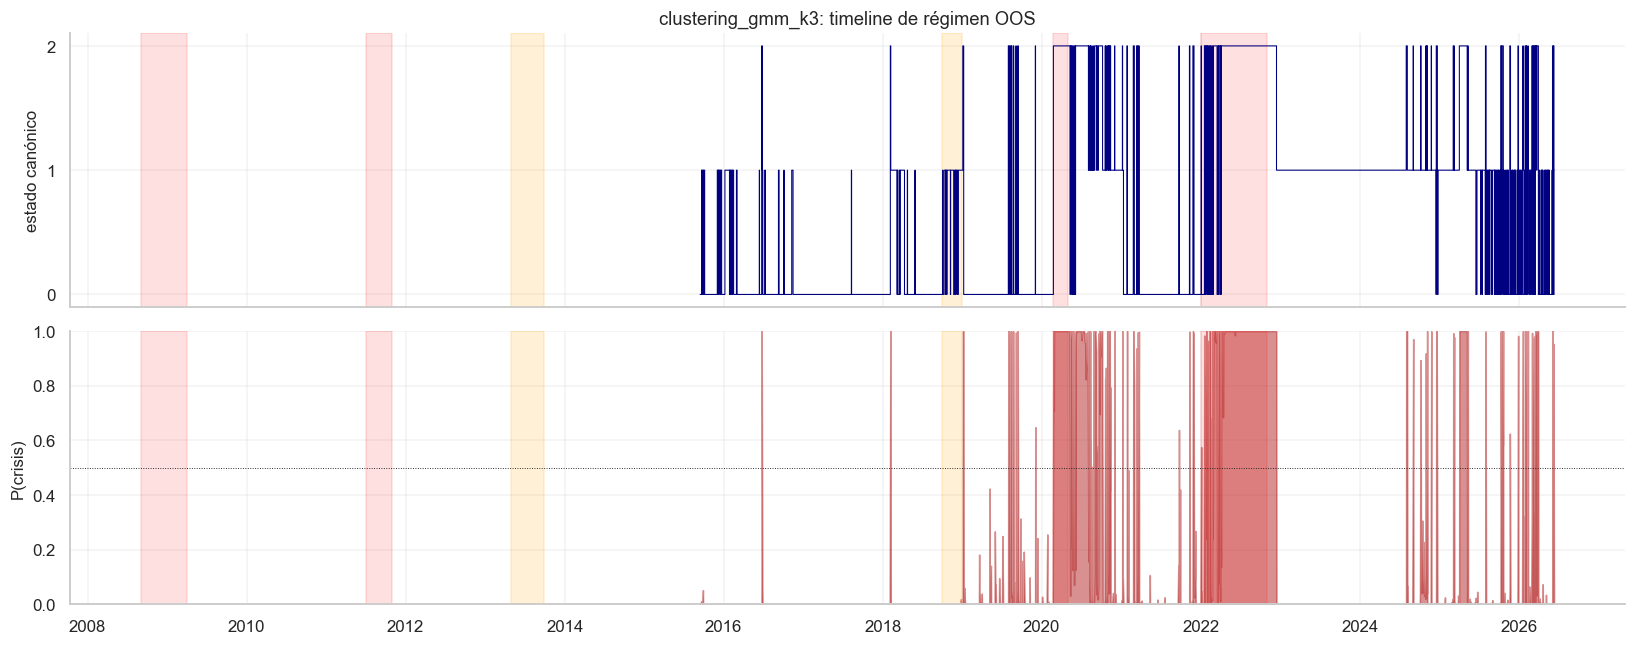

In [11]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
a1.step(st.index, st.values, where='post', color='navy', lw=0.7)
a1.set_ylabel('estado canónico'); a1.set_yticks(range(det.n_states))
a1.set_title(f'{det.name}: timeline de régimen OOS')
a2.fill_between(panel.index, panel['p_crisis'].values, 0, color='firebrick', alpha=0.5)
a2.axhline(0.5, color='k', lw=0.6, ls=':'); a2.set_ylabel('P(crisis)'); a2.set_ylim(0, 1)
for axx in (a1, a2):
    for name, (a, b) in ev.CRISIS_WINDOWS.items():
        axx.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
    for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
        axx.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.16)
fig.tight_layout(); fig.savefig(RESULTS / 'd03_gmm_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

<a id="s11"></a>
## 11. Verificación contra crisis y trampas

Contrastamos las etiquetas OOS con un calendario de eventos conocidos, con un criterio de éxito declarado por ventana:

- **2008 (GFC) / 2011 (deuda europea):** esperamos `NaN`. Caen dentro del primer train (la ventana 2007 de las features no deja histórico previo suficiente), así que NO son OOS-evaluables. El `NaN` es el comportamiento CORRECTO, no un acierto ni un fallo.
- **2020 (COVID) / 2022 (Inflación):** cobertura de crisis (sensibilidad); cuanto más alta, mejor.
- **2013 (taper tantrum) / 2018 (sell-off del Q4):** trampas —episodios que NO deberían marcarse como crisis sostenida—; un falso-positivo bajo es lo deseable. 2013 cae también fuera de OOS → `NaN`.

In [12]:
cov = res.crisis_coverage; fap = res.false_alarm_in_fp
def fmt(d):
    return {k: ('NaN (fuera de OOS)' if v != v else round(v, 3)) for k, v in d.items()}
print('OOS efectivo:', res.extra['ventana_eval'])
print('Cobertura crisis :', fmt(cov))
print('Falsos positivos :', fmt(fap))
print('false_alarm_rate global:', round(res.false_alarm_rate, 3))
assert cov['GFC_2008'] != cov['GFC_2008'], '2008 deberia ser NaN'
assert cov['EuroDebt_2011'] != cov['EuroDebt_2011'], '2011 deberia ser NaN'
assert cov['COVID_2020'] == cov['COVID_2020'] and cov['Inflation_2022'] == cov['Inflation_2022']
print('\nVERIFICACION OK: 2008/2011 = NaN (esperado); COVID/Inflacion evaluables.')

OOS efectivo: 2015-09-15→2026-06-12 (n=2649)
Cobertura crisis : {'GFC_2008': 'NaN (fuera de OOS)', 'EuroDebt_2011': 'NaN (fuera de OOS)', 'COVID_2020': 0.96, 'Inflation_2022': 0.865}
Falsos positivos : {'TaperTantrum_2013': 'NaN (fuera de OOS)', 'Selloff_Q4_2018': 0.0}
false_alarm_rate global: 0.494

VERIFICACION OK: 2008/2011 = NaN (esperado); COVID/Inflacion evaluables.


---
<a id="s12"></a>
## 12. Conclusión D3 — veredicto "mejor-para-qué"

GMM estático con covarianza full, evaluado OOS desde 2015 (2008/2011 no evaluables por la ventana 2007 de las features). El balance es nítido y **consistente con** la hipótesis del CHECKPOINT 2, sin contradecirla:

- **Dónde acierta:** capta COVID-2020 e Inflación-2022 con cobertura alta. La covarianza full le permite ver el cambio de estructura de correlación que un *k-means* euclídeo no separaría —es un baseline interpretable y sensible a las crisis grandes—.
- **Dónde falla:** exhibe **flickering severo** (`switching_rate` alto, rachas de pocos días), lo que lo descarta como detector operativo: un "régimen" que dura una semana no es un régimen.
- **Para qué sirve, entonces:** no como detector definitivo, sino como **baseline NO temporal** que aísla el aporte de la dinámica markoviana. La pregunta que deja abierta —¿cuánta de esa fragmentación elimina una matriz de transición?— la responde D4 con las mismas features.
- **El mecanismo, ahora visible (Bloque B):** el *scatter* PCA (`d03_feature_scatter.png`) muestra los tres componentes ocupando regiones separables del espacio de features, con la crisis en la cola; los heatmaps por componente (`d03_cov_by_component.png`) confirman que cada gaussiana tiene una **estructura de covarianza distinta** —el aporte real de `covariance_type='full'`, que un *k-means* euclídeo no vería—; y el paisaje BIC (`d03_bic_curve.png`) justifica *k*=3 y, vía la confianza de asignación, expone los **días-frontera** de baja responsabilidad que explican el flickering. Es decir: el GMM *sí* separa estructura, pero la decisión día-a-día sin memoria es lo que lo descarta como detector operativo.

Detalle y números finales en `docs/memory/detectors/03_clustering_gmm.md`.